2D activation plots for addition neurons, to see their periodic behavior as you vary input concept and offset. 

To run this, you need to cache the activations first. Run: `python src/cache_neuron_activations.py --tasks weekdays months hours addition --layer 18`

In [ ]:
import matplotlib.pyplot as plt 
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.size"] = 14

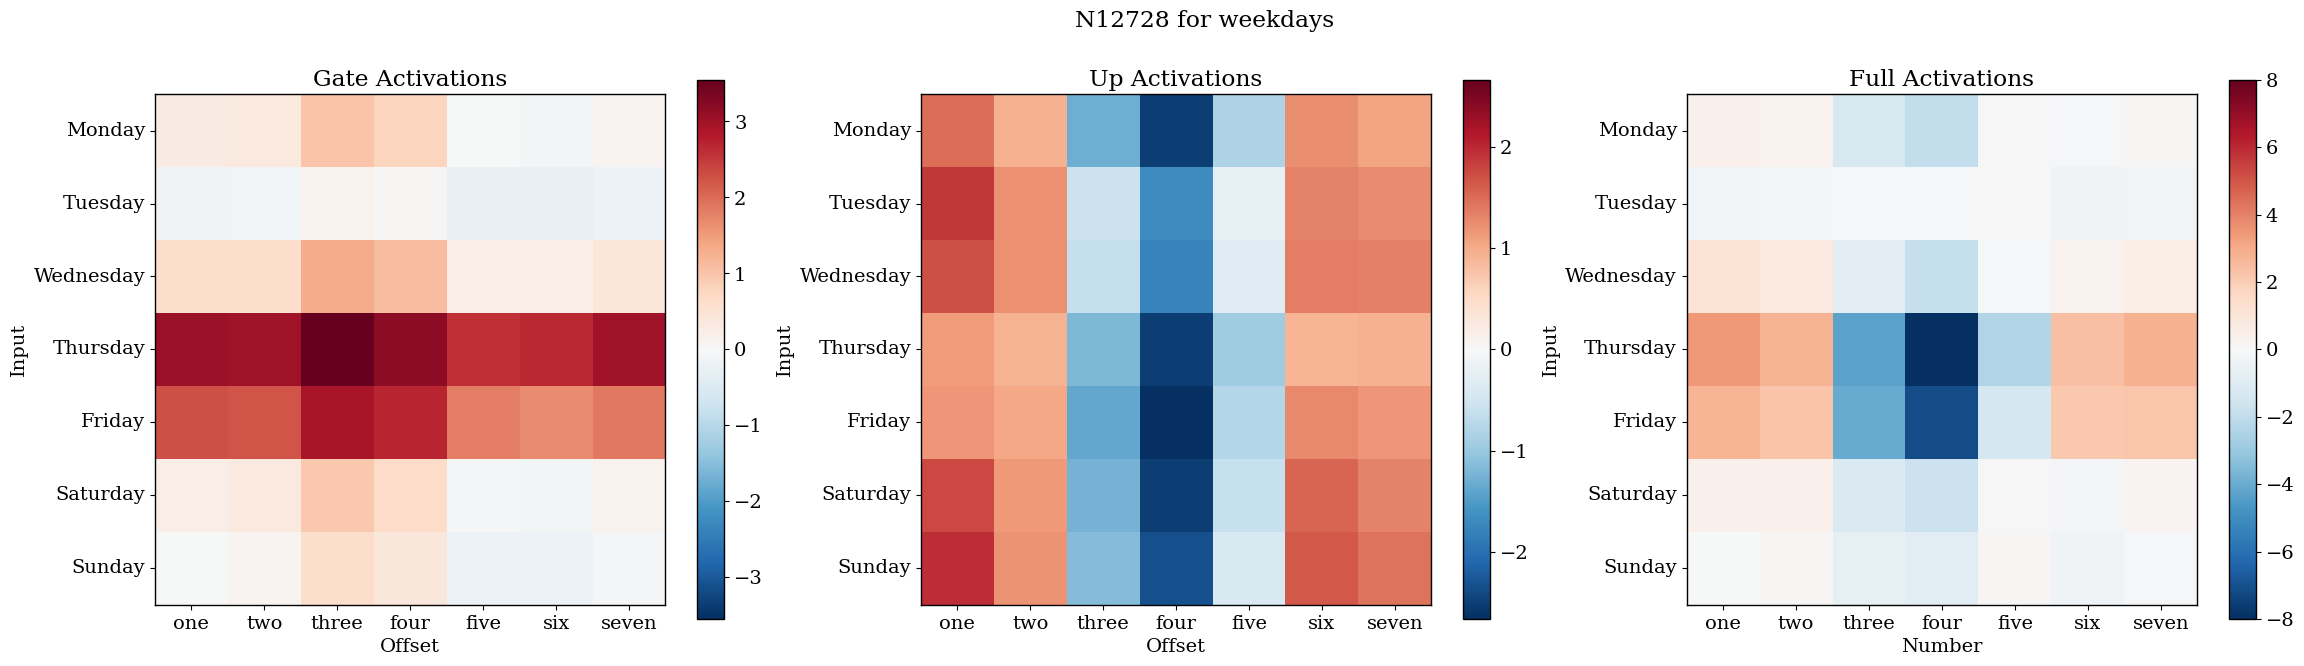

In [ ]:
import torch
import seaborn as sns
from tasks import TASKS

layer = 18
neuron = 12728
task = "weekdays"

gate_mlp_acts = torch.load(f"../outputs/neuron_activations/Llama-3.1-8B/{task}_L{layer}/gate_mlp_acts.pt")
up_mlp_acts = torch.load(f"../outputs/neuron_activations/Llama-3.1-8B/{task}_L{layer}/up_mlp_acts.pt")
both_mlp_acts = torch.load(f"../outputs/neuron_activations/Llama-3.1-8B/{task}_L{layer}/both_mlp_acts.pt")

cm = TASKS[task]["causal_model"]
inps = cm.values["input"]
nums = cm.values["offset"]

maxinp = len(inps)
maxnum = len(inps)

if task != "addition":
    xticks = nums[:maxnum]
    yticks = inps[:maxinp]
else:
    xticks=[n if int(n) % 5 == 0 else "" for n in nums]
    yticks=[n if int(n) % 5 == 0 else "" for n in inps]

fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(28,7))

# up activations 
axs[0].set_title(f'Gate Activations')
to_plot = gate_mlp_acts[:, :, neuron].cpu().T[:maxinp, :maxnum]
plot_v = torch.abs(to_plot).max().item()
sns.heatmap(
    to_plot, 
    ax=axs[0], 
    xticklabels=xticks,
    yticklabels=yticks,
    square=True,
    cmap='RdBu_r', 
    vmax=plot_v, vmin=-plot_v, 
    rasterized=True
) 
for spine in axs[0].spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(1) 
axs[0].set_ylabel('Input')
axs[0].set_xlabel('Offset')
axs[0].collections[0].colorbar.outline.set_visible(True)                                                                                                                                                              
axs[0].collections[0].colorbar.outline.set_linewidth(1)

# up activations 
axs[1].set_title(f'Up Activations')
to_plot = up_mlp_acts[:, :, neuron].cpu().T[:maxinp, :maxnum]
plot_v = torch.abs(to_plot).max().item()
sns.heatmap(
    to_plot, 
    ax=axs[1], 
    xticklabels=xticks,
    yticklabels=yticks,
    square=True,
    cmap='RdBu_r', 
    vmax=plot_v, vmin=-plot_v, 
    rasterized=True
) 
for spine in axs[1].spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(1) 
axs[1].set_ylabel('Input')
axs[1].set_xlabel('Offset')
axs[1].collections[0].colorbar.outline.set_visible(True)                                                                                                                                                              
axs[1].collections[0].colorbar.outline.set_linewidth(1)

# full activations 
axs[2].set_title(f'Full Activations')
to_plot = both_mlp_acts[:, :, neuron].cpu().T[:maxinp, :maxnum]
plot_v = torch.abs(to_plot).max().item()
sns.heatmap(
    to_plot, 
    ax=axs[2], 
    xticklabels=xticks,
    yticklabels=yticks,
    square=True,
    cmap='RdBu_r', 
    vmax=plot_v, vmin=-plot_v, 
    rasterized=True
) 
for spine in axs[2].spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(1) 
axs[2].set_ylabel('Input')
axs[2].set_xlabel('Number')
axs[2].collections[0].colorbar.outline.set_visible(True)                                                                                                                                                              
axs[2].collections[0].colorbar.outline.set_linewidth(1)

plt.suptitle(f"N{neuron} for {task}")
plt.show()